# Music Genre Classification with Convolutional Neural Networks
We follow https://www.kdnuggets.com/2020/02/audio-data-analysis-deep-learning-python-part-2.html.<br>

See DFT, STFT, Spectrograms and MFCCs.ipynb and librosa Audio Feature Extraction.ipynb for review.<br>

We use the *GTZAN Genre Collection* dataset, available at http://marsyas.info/downloads/datasets.html. Our task is to build a model that classifies a music excerpt into music genres. <br>

Previously in master_DNN.ipynb, we constructed spectrograms from the audio (.wav) file and extract spectral features. We used the spectral features as inputs to build a deep neural network, and achieved a validation set accuracy of 0.69. <br>

In this notebook, with the spectrogram image files as inputs, we construct a convolutional neural network for the classification task.<br>

Read master_DNN.ipynb first.

## Workflow:
[0. Global variables](#gv)<br>
[1. Dataset: preliminary pre-processing](#a)<br>
[2. Convert audio files into spectrograms and MFCCs, store in PNG format](#b)<br>
[3. Spectrogram/MFCC: image pre-processing, augmentation and train-validation split](#d)<br>
[4. Convolutional neural network](#e)<br>

## Preamble

In [1]:
import IPython.display as ipyd
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import pandas as pd
# # Make the output look better
# pd.set_option('display.max_rows', 500)
# pd.set_option('display.max_columns', 500)
# # pd.set_option('display.width', 1000)
pd.options.mode.chained_assignment = None  # default='warn' # ignores warning about dropping columns inplace

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.preprocessing import OneHotEncoder

# from xgboost import XGBClassifier

from scipy import signal
from scipy.io import wavfile    # load wave files
import librosa                  # package for music and audio analysis
import librosa.display

from PIL import Image    # load image

import os
os.chdir(r'C:\Users\Cedric Yu\Desktop\Data Science\Audio Data Analysis\1_GTZAN_genre_classification')

In [2]:
# tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_addons as tfa # import tfa which contains metrics for regression
from tensorflow.keras import regularizers

from tensorflow.random import set_seed
set_seed(0)

from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array

# generate batches of tensor image data with real-time data augmentation
# train-validation split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### <code>tensorflow.keras.preprocessing.image.ImageDataGenerator</code>

- Pre-process (e.g. rescale pixel values) and augment (e.g. rotate) images
- Assign binary labels to training set, using <code>mageDataGenerator(...).flow_from_directory</code>.
- Set up data generators that read pictures in the source folders, convert them to float32 tensors, and feed them (with their labels) to a neural network 
- There will be one generator for the training images and one for the validation images
- The ImageDataGenerator class allows to instantiate generators of *augmented* image batches, and their labels via <code>.flow(data, labels)</code> or <code>.flow_from_directory(directory)</code>
- These generators can then be used with the Keras model methods that accept data generators as inputs: <code>fit</code>, <code>evaluate_generator</code>, and <code>predict_generator</code><br>

**Augmentation with ImageDataGenerator**<br>

- <code>rotation_range</code>:	Int. Degree range for random rotations.
- <code>width_shift_range</code>:	float: fraction of total width, if < 1, or pixels if >= 1.
- <code>height_shift_range</code>: float: fraction of total height, if < 1, or pixels if >= 1.
- <code>brightness_range</code>: Tuple or list of two floats. Range for picking a brightness shift value from.
- <code>shear_range</code>: Float. Shear Intensity (Shear angle in counter-clockwise direction in degrees)
- <code>zoom_range</code>:	Float or [lower, upper]. Range for random zoom. If a float, [lower, upper] = [1-zoom_range, 1+zoom_range].
- <code>channel_shift_range</code>:	Float. Range for random channel shifts.
- <code>horizontal_flip</code>: Boolean. Randomly flip inputs horizontally.
- <code>vertical_flip</code>: Boolean. Randomly flip inputs vertically.
- <code>fill_mode = 'nearest'</code><br>

#### Typical workflow

1. Define <code>ImageDataGenerator</code> separately for the training and validation sets. <br>
Rescale pixel values from 0-255 to between 0 and 1 using <code>rescale=1./255</code> because the pixel range 0-255 is too high for the model to process (given a typical learning rate). <br>
Choose a validation_split (e.g. 0.2). <br>
Augment images *in the training set only*.<br>

<code>train_datagen = ImageDataGenerator(rescale=1./255,
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest', 
      validation_split = 0.2) </code>

<code>valid_datagen = ImageDataGenerator(rescale=1./255,
      validation_split = 0.2) </code>

2. Take the path to a directory and generate batches of augmented data.<br>
Use the *same seed* for both train and validation generators to avoid leakage.<br>

<code>train_generator = train_datagen.flow_from_directory(train_dir, batch_size=20, class_mode='binary', target_size=(input_width, input_height), subset = 'training', seed = 42)</code>

<code>valid_generator = valid_datagen.flow_from_directory(train_dir, batch_size=20, class_mode='binary', target_size=(input_width, input_height), subset = 'validation', seed = 42) </code><br>

In each of the resulting generators, the first index labels the batch number (which batch we are in). Each batch is a 2-tuple, where the first object contains the processed images, and the second contains the one-hot encoded labels.<br>

3. To train a model, use<br>

<code>history = model.fit(train_generator, validation_data = valid_generator, epochs = 40)</code><br>

4. Model predictions:<br>

<code>model.evaluate(valid_generator)</code>, <code>model.predict(test_preprocessed) > 0.5).astype(int)</code>, etc.

## Global variables<a class="anchor" id="gv"></a>

In [3]:
num_class = 10

# raw audio file and STFT parameters
mono = True    # mono channel
duration = 30    # 30 seconds
sr = 22050    # sample rate = 22050 Hz
n_fft = 551     # n_fft = 0.025 ms * 22050 Hz
hop_length = 220    # hop_length = 0.01 ms * 22050 Hz

# parameters for the spectral features
roll_percent = 0.85    # roll-off percentage in spectral rolloff
n_mfcc = 20    # number of MFCCs to return

# set dimensions of the input spectrograms
input_width = 334
input_height = 217
# both spectrograms and mfccs are actually grayscale
num_channels = 1
color_mode='grayscale'

# parameters in ImageDataGenerator
width_shift_range=0.2
# for MFCCs, only shift width
height_shift_range=0.2 # 0.2
shear_range=0.2 # 0.2
zoom_range=0.2 # 0.2
fill_mode='nearest'

# validation set split
validation_split = 0.2
batch_size = 20

## 1. Dataset: preliminary pre-processing<a class="anchor" id="a"></a>

The 10 genres in the dataset are:
1. Blues
2. Classical
3. Country
4. Disco
5. Hiphop
6. Jazz
7. Metal
8. Pop
9. Reggae
10. Rock

Each genre has its own directory storing the audio tracks to which they belong. Each genre has 100 audio tracks, each being a ~30 second, 22050Hz Mono 16-bit audio file in .wav format.




### Get genre and file names

In [4]:
# list of genres
genres_list = os.listdir('genres/')
genres_list.sort()

In [5]:
print(genres_list)

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [6]:
genres_encode = dict(zip(genres_list, range(len(genres_list))))
genres_decode = dict(zip(range(len(genres_list)), genres_list))

In [7]:
# wav_filenames is a dict that stores the list of file names in each genre folder
wav_filenames = {}
for genre in genres_list:
    wav_filenames[genre] = os.listdir('genres/'+genre+'/')
    wav_filenames[genre].sort()

# 2. Convert audio files into spectrograms and MFCCs, store in PNG format<a class="anchor" id="b"></a>

In [27]:
# run only once
# construct spectrograms and save to PNG files

for genre in tqdm(genres_list):
    
    # create destination directories for output PNG files if not exist
    if not os.path.exists('spectrograms/' + genre):
        os.makedirs('spectrograms/' + genre)
    
    filenames = wav_filenames[genre]
    
    for wav_filename in filenames:
        
        # use librosa.load() to load audio file
        filename = 'genres/' + genre + '/' + wav_filename
        x , _ = librosa.load(filename, sr=sr, mono=mono, duration=duration)
        
        # short-time fast Fourier transform (STFFT)
        stfft = librosa.stft(x, n_fft=n_fft, hop_length=hop_length)
        abs_stfft = np.abs(stfft)
        # convert amplitude to dB scale
        stfftdB = librosa.amplitude_to_db(abs_stfft, ref=np.max)
        
        # Plot spectrogram, without x- and y-axes
        # Plots like this will be stored in PNG format for future use
        img = librosa.display.specshow(stfftdB, sr=sr, hop_length=hop_length,
                                       y_axis='hz', x_axis='time', 
                                       # grayscale
                                       cmap='gray_r')
        plt.axis('off');
        # save to PNG file
        plt.savefig('spectrograms/' + genre + '/' + wav_filename[:-4] + '.png', 
                    bbox_inches='tight', pad_inches=0)  # no white margins
        plt.close()
        
        

100%|██████████| 10/10 [09:10<00:00, 55.06s/it]


In [ ]:
# run only once
# construct mfccs and save to PNG files

for genre in tqdm(genres_list):
    
    # create destination directories for output PNG files if not exist
    if not os.path.exists('mfccs/' + genre):
        os.makedirs('mfccs/' + genre)
    
    filenames = wav_filenames[genre]
    
    for wav_filename in filenames:
        
        # use librosa.load() to load audio file
        filename = 'genres/' + genre + '/' + wav_filename
        x , _ = librosa.load(filename, sr=sr, mono=mono, duration=duration)
        
        # MFCCs
        mfccs = librosa.feature.mfcc(x, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
        
        # Plot spectrogram, without x- and y-axes
        # Plots like this will be stored in PNG format for future use
        img = librosa.display.specshow(mfccs, x_axis='time', 
                                       sr=sr_sample, hop_length=hop_length_sample, 
                                       # grayscale
                                       cmap='gray_r');
        plt.axis('off');
        # save to PNG file
        plt.savefig('mfccs/' + genre + '/' + wav_filename[:-4] + '.png', 
                    bbox_inches='tight', pad_inches=0)  # no white margins
        plt.close()
        
        

In [8]:
# create dictionary for spectrogram_filenames
# stores the list of file names in each genre folder
spectrogram_filenames = {}
for genre in genres_list:
    spectrogram_filenames[genre] = os.listdir('spectrograms/'+genre+'/')
    spectrogram_filenames[genre].sort()

In [9]:
# create dictionary for mfcc_filenames
# stores the list of file names in each genre folder
mfcc_filenames = {}
for genre in genres_list:
    mfcc_filenames[genre] = os.listdir('mfccs/'+genre+'/')
    mfcc_filenames[genre].sort()

spectrograms/blues/blues.00003.png


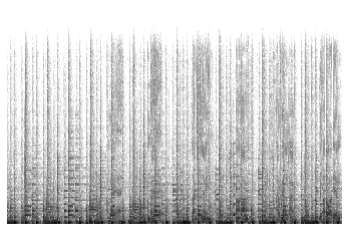

In [30]:
spectrogram_filename_sample = 'spectrograms/' + 'blues' + '/' + spectrogram_filenames['blues'][3]
im_sample = Image.open(spectrogram_filename_sample)
print(spectrogram_filename_sample)
plt.imshow(im_sample);
plt.axis('off');

mfccs/blues/blues.00003.png


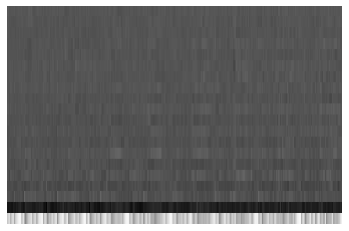

In [12]:
mfcc_filename_sample = 'mfccs/' + 'blues' + '/' + mfcc_filenames['blues'][3]
im_sample = Image.open(mfcc_filename_sample)
print(mfcc_filename_sample)
plt.imshow(im_sample);
plt.axis('off');

## 3. Spectrogram/MFCC: image pre-processing, augmentation and train-validation split<a class="anchor" id="d"></a>

### Loads and prepare an image for data exploration

In [31]:
# load and prepare an image
def load_image_pixels(filename, shape=None):
    # load the image to get its shape
    image = load_img(filename)
    # record the original image shape
    width, height = image.size
    # load the image with the required size (target_size=None means original image size)
    image = load_img(filename, target_size=shape)
    # convert to numpy array
    image = img_to_array(image)
    # scale pixel values to [0, 1]
    image = image.astype('float32')
    # image /= 255.0
    # add a dimension so that we have one sample
    # image = expand_dims(image, 0)
    return image, width, height

In [32]:
spectrogram_filename_sample = 'spectrograms/' + 'blues' + '/' + spectrogram_filenames['blues'][3]
image_sample, width_sample, height_sample = load_image_pixels(spectrogram_filename_sample)
print(width_sample, height_sample)
print(image_sample.shape)
# range of pixel values
print(np.ptp(image_sample) + 1)

334 217
(217, 334, 3)
254.0


In [33]:
mfcc_filename_sample = 'mfccs/' + 'blues' + '/' + mfcc_filenames['blues'][3]
image_sample, width_sample, height_sample = load_image_pixels(mfcc_filename_sample)
print(width_sample, height_sample)
print(image_sample.shape)
# range of pixel values
print(np.ptp(image_sample) + 1)

334 217
(217, 334, 3)
246.0


### Define <code>ImageDataGenerator</code>

In [10]:
train_datagen = ImageDataGenerator(rescale=1./255,   
                                   # the pixel range 0-255 is too high for the model to process (given a typical learning rate)
                                   # set target values between 0 and 1 instead by scaling with a 1/255
                                   width_shift_range=width_shift_range,
                                   height_shift_range=height_shift_range,
                                   shear_range=shear_range,
                                   zoom_range=zoom_range,
                                   fill_mode=fill_mode, 
                                   validation_split=validation_split)

valid_datagen = ImageDataGenerator(rescale=1./255, 
                                   validation_split=validation_split)

### Take the path to a directory and generate batches of augmented data

In [11]:
train_dir = 'spectrograms/'
# train_dir = 'mfccs/'

In [12]:
train_generator = train_datagen.flow_from_directory(train_dir, batch_size=batch_size, 
                                                    class_mode='categorical', 
                                                    target_size=(input_width, input_height), 
                                                    color_mode=color_mode,
                                                    subset = 'training', seed = 42) 

Found 800 images belonging to 10 classes.


In [13]:
# flow validation images in batches of 20 using valid_datagen generator
valid_generator =  valid_datagen.flow_from_directory(train_dir, batch_size=batch_size, 
                                                     class_mode='categorical', 
                                                     target_size=(input_width, input_height), 
                                                     color_mode=color_mode,
                                                     subset = 'validation', seed = 42) 

Found 200 images belonging to 10 classes.


In [14]:
print(train_generator[0][0].shape)
print(train_generator[0][1].shape)

(20, 334, 217, 1)
(20, 10)


In [17]:
# list some shuffled filenames to verify that the labels are correct
for j, img in enumerate(train_generator):
    if j > 0: break
    idx = (train_generator.batch_index - 1) * train_generator.batch_size
    print([train_generator.filenames[train_generator.index_array[i]] for i in range(idx, idx + train_generator.batch_size)])

['disco\\disco.00034.png', 'metal\\metal.00030.png', 'pop\\pop.00075.png', 'rock\\rock.00063.png', 'blues\\blues.00084.png', 'reggae\\reggae.00055.png', 'blues\\blues.00070.png', 'country\\country.00098.png', 'jazz\\jazz.00070.png', 'hiphop\\hiphop.00041.png', 'metal\\metal.00023.png', 'blues\\blues.00094.png', 'classical\\classical.00058.png', 'hiphop\\hiphop.00066.png', 'metal\\metal.00064.png', 'rock\\rock.00084.png', 'country\\country.00041.png', 'reggae\\reggae.00084.png', 'classical\\classical.00079.png', 'blues\\blues.00091.png']


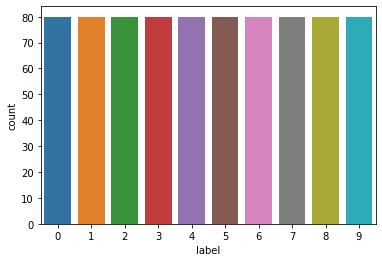

In [40]:
train_labels = np.array([train_generator[i][1].argmax(axis=1).squeeze().tolist() for i in range(int(800/batch_size))]).flatten()
sns.countplot(x='label', data=pd.DataFrame(train_labels, columns=['label']));

Train-validation split is stratified in the classes.

## 4. Convolutional neural network<a class="anchor" id="e"></a>

In [15]:
cnn_model = tf.keras.Sequential([
    layers.Conv2D(32, kernel_size=(3,3), strides=(2, 2), padding='same', activation = 'relu', 
                  input_shape = (input_width, input_height, num_channels)),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(64, (3,3), padding='same', activation = 'relu'),
    layers.MaxPooling2D(2,2), 
    
    layers.Conv2D(64, (3,3), padding='same', activation = 'relu'), 
    layers.MaxPooling2D(2,2),
    
    # flatten the results to feed into a DNN
    layers.Flatten(), 
    layers.Dropout(0.2),
    # 512 neuron hidden layer
    layers.Dense(64, activation = 'relu'), 
    layers.Dropout(0.2),
    layers.Dense(units=num_class, activation='softmax')
    ]) 

In [25]:
from tensorflow.keras.optimizers.schedules import PolynomialDecay

lr_decay = PolynomialDecay(initial_learning_rate = 0.00005, 
                           decay_steps = 20, 
                           end_learning_rate=0.000001, 
                           power = 2)

optimizer = tf.keras.optimizers.Adam(learning_rate = lr_decay)
cnn_model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=['categorical_accuracy']
)


callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_categorical_accuracy', 
    mode = 'max', patience=40, 
    min_delta = 0.00001, 
    restore_best_weights=True)

In [26]:
history = cnn_model.fit(train_generator, validation_data = valid_generator,
                    epochs = 500, callbacks = [callback])

Epoch 1/500
40/40 [==============================] - 5s 106ms/step - loss: 2.0921 - categorical_accuracy: 0.2175 - val_loss: 2.1055 - val_categorical_accuracy: 0.1850
Epoch 2/500
40/40 [==============================] - 4s 102ms/step - loss: 2.0863 - categorical_accuracy: 0.2350 - val_loss: 2.1008 - val_categorical_accuracy: 0.1800
Epoch 3/500
40/40 [==============================] - 4s 103ms/step - loss: 2.0999 - categorical_accuracy: 0.2163 - val_loss: 2.0973 - val_categorical_accuracy: 0.1950
Epoch 4/500
40/40 [==============================] - 4s 106ms/step - loss: 2.0782 - categorical_accuracy: 0.2362 - val_loss: 2.0967 - val_categorical_accuracy: 0.1950
Epoch 5/500
40/40 [==============================] - 4s 107ms/step - loss: 2.0767 - categorical_accuracy: 0.2412 - val_loss: 2.0915 - val_categorical_accuracy: 0.2000
Epoch 6/500
40/40 [==============================] - 4s 108ms/step - loss: 2.0627 - categorical_accuracy: 0.2225 - val_loss: 2.0904 - val_categorical_accuracy: 0.205

Epoch 50/500
40/40 [==============================] - 4s 101ms/step - loss: 2.0313 - categorical_accuracy: 0.2825 - val_loss: 2.0671 - val_categorical_accuracy: 0.2750
Epoch 51/500
40/40 [==============================] - 4s 103ms/step - loss: 2.0392 - categorical_accuracy: 0.2825 - val_loss: 2.0653 - val_categorical_accuracy: 0.2800
Epoch 52/500
40/40 [==============================] - 4s 104ms/step - loss: 2.0228 - categorical_accuracy: 0.2763 - val_loss: 2.0665 - val_categorical_accuracy: 0.2750
Epoch 53/500
40/40 [==============================] - 4s 102ms/step - loss: 2.0518 - categorical_accuracy: 0.2688 - val_loss: 2.0644 - val_categorical_accuracy: 0.2800
Epoch 54/500
40/40 [==============================] - 4s 110ms/step - loss: 2.0375 - categorical_accuracy: 0.2663 - val_loss: 2.0648 - val_categorical_accuracy: 0.2800
Epoch 55/500
40/40 [==============================] - 4s 112ms/step - loss: 2.0346 - categorical_accuracy: 0.2875 - val_loss: 2.0663 - val_categorical_accuracy:

In [27]:
history_df = pd.DataFrame(history.history)

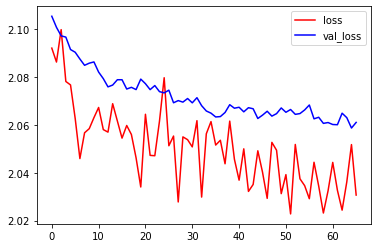

In [29]:
plt.figure()
plt.plot(history.history['loss'][:], color='red', label='loss')
plt.plot(history.history['val_loss'][:], color='blue', label='val_loss')
plt.legend();

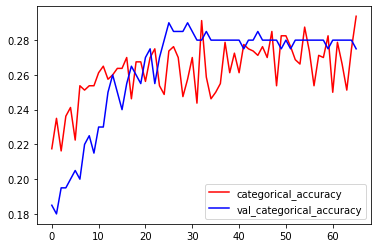

In [28]:
plt.figure()
plt.plot(history.history['categorical_accuracy'][:], color='red', label='categorical_accuracy')
plt.plot(history.history['val_categorical_accuracy'][:], color='blue', label='val_categorical_accuracy')
plt.legend();

In [30]:
cnn_model.evaluate(train_generator)

40/40 [==============================] - 4s 97ms/step - loss: 2.0309 - categorical_accuracy: 0.2837


[2.03090763092041, 0.2837499976158142]

In [31]:
cnn_model.evaluate(valid_generator)

10/10 [==============================] - 1s 39ms/step - loss: 2.0745 - categorical_accuracy: 0.2900


[2.074537754058838, 0.28999999165534973]

#### MFCC training curves

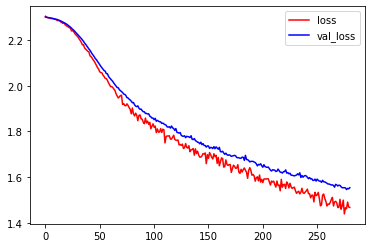

In [27]:
plt.figure()
plt.plot(history.history['loss'][:], color='red', label='loss')
plt.plot(history.history['val_loss'][:], color='blue', label='val_loss')
plt.legend();

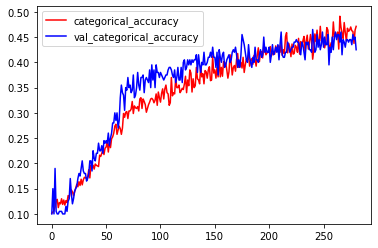

In [28]:
plt.figure()
plt.plot(history.history['categorical_accuracy'][:], color='red', label='categorical_accuracy')
plt.plot(history.history['val_categorical_accuracy'][:], color='blue', label='val_categorical_accuracy')
plt.legend();

In [29]:
cnn_model.evaluate(train_generator)

40/40 [==============================] - 3s 72ms/step - loss: 1.4245 - categorical_accuracy: 0.5063


[1.4245390892028809, 0.5062500238418579]

In [30]:
cnn_model.evaluate(valid_generator)

10/10 [==============================] - 1s 36ms/step - loss: 1.6050 - categorical_accuracy: 0.4650


[1.6050083637237549, 0.4650000035762787]

### Prediction: set <code>shuffle=False</code> in <code>ImageDataGenerator.flow_from_directory</code> for definite predictions

In [29]:
train_generator_no_shuffle = train_datagen.flow_from_directory(train_dir, batch_size=batch_size, 
                                                    class_mode='categorical', 
                                                    target_size=(input_width, input_height), 
                                                    subset = 'training', seed = 42, 
                                                               color_mode=color_mode,
                                                              shuffle=False) 

Found 800 images belonging to 10 classes.


In [30]:
# flow validation images in batches of 20 using valid_datagen generator
# set shuffle=False for prediction
valid_generator_no_shuffle =  valid_datagen.flow_from_directory(train_dir, batch_size=batch_size, 
                                                     class_mode='categorical', 
                                                     target_size=(input_width, input_height), 
                                                     subset = 'validation', seed = 42, 
                                                                color_mode=color_mode,
                                                                shuffle=False) 

Found 200 images belonging to 10 classes.


In [31]:
from sklearn.metrics import accuracy_score

In [32]:
y_train_pred = cnn_model.predict(train_generator_no_shuffle).argmax(axis=-1)
y_train = np.array([train_generator_no_shuffle[i][1].argmax(axis=1).squeeze().tolist() for i in range(int(800/batch_size))]).flatten()

In [33]:
accuracy_score(y_train, y_train_pred)

0.19875

In [34]:
y_valid_pred = cnn_model.predict(valid_generator_no_shuffle).argmax(axis=-1)
y_valid = np.array([valid_generator_no_shuffle[i][1].argmax(axis=1).squeeze().tolist() for i in range(int(200/batch_size))]).flatten()

In [35]:
accuracy_score(y_valid, y_valid_pred)

0.27

In [20]:
cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 167, 109, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 83, 54, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 83, 54, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 41, 27, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 41, 27, 64)        36928     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 20, 13, 64)       0

### Using spectral features, our deep neural network achieved a validation set accuracy of 0.69. It overfits as the training set accuracy is 0.75.

### Using the coloured spectrograms, our convolution neural network achieved a validation set accuracy of 0.385. The training set accuracy is 0.37625. Thus, the model has low bias and low variance. More training data are needed.

### Using the *grayscaled* spectrograms, our convolution neural network achieved a validation set accuracy of 0.290. The training set accuracy is 0.284. Thus, the model has low bias and low variance. More training data are needed.

### Using the *grayscale* MFCCs, our convolution neural network achieved a validation set accuracy of 0.465. The training set accuracy is 0.506. Thus, the model has low bias and low variance. More training data are needed.

In [71]:
# tf.keras.backend.clear_session()

# from numba import cuda 
# device = cuda.get_current_device()
# device.reset()